170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 151s 308ms/step - accuracy: 0.7835 - loss: 0.5194 - val_accuracy: 0.7348 - val_loss: 0.6459
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 302ms/step - accuracy: 0.8803 - loss: 0.2894 - val_accuracy: 0.9228 - val_loss: 0.1934
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - accuracy: 0.8999 - loss: 0.2464 - val_accuracy: 0.9293 - val_loss: 0.1801
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 304ms/step - accuracy: 0.9088 - loss: 0.2298 - val_accuracy: 0.7115 - val_loss: 0.7584
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 296ms/step - accuracy: 0.9176 - loss: 0.2105 - val_accuracy: 0.9290 - val_loss: 0.1873
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 295ms/step - accuracy: 0.9248 - loss: 0.1905 - val_accuracy: 0.9395 - val_loss: 0.1541
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 299ms/step - accuracy: 0.9212 - loss: 0.1944 - val_accuracy: 0.9250 - val_loss: 0.1991
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 301ms/step - accuracy: 0.9260 - los

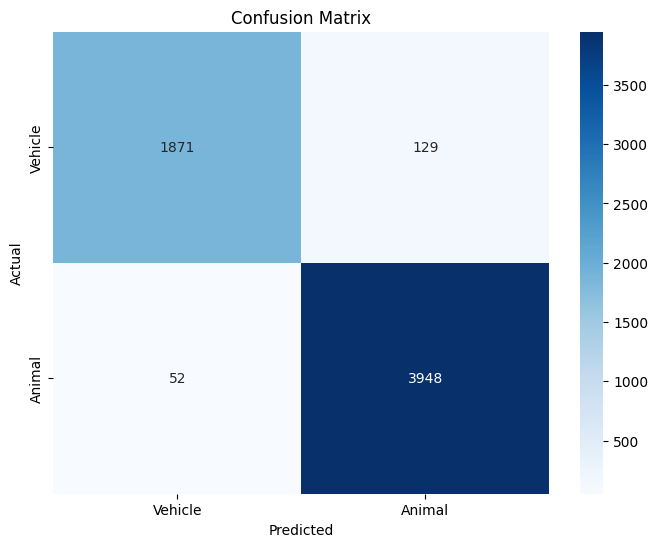

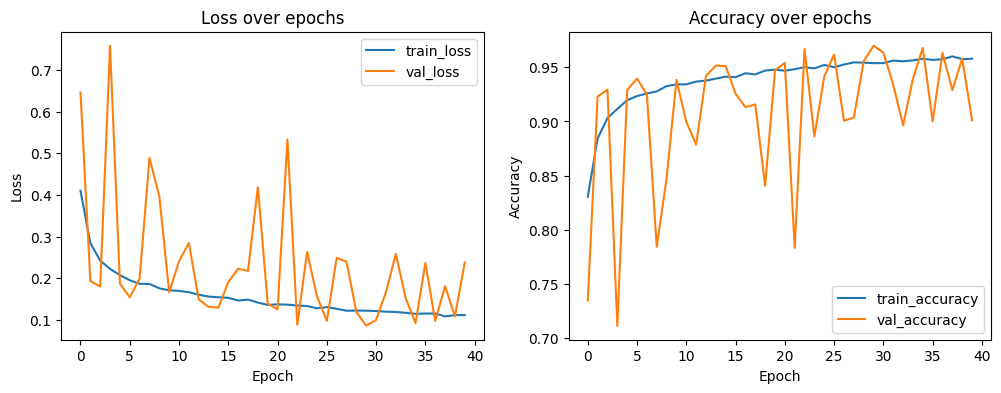

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricare i dati
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalizzare le immagini
x_train, x_test = x_train / 255.0, x_test / 255.0

# Classi di interesse: veicoli e animali
vehicle_classes = [1, 9]  # automobile, camion
animal_classes = [2, 3, 5, 7]  # uccello, gatto, cane, cavallo

# Funzione per filtrare e rimappare le etichette
def filter_and_remap_data(x, y, vehicle_classes, animal_classes):
    vehicle_indices = [i for i, label in enumerate(y) if label[0] in vehicle_classes]
    animal_indices = [i for i, label in enumerate(y) if label[0] in animal_classes]
    indices = vehicle_indices + animal_indices
    x_filtered = x[indices]
    y_filtered = y[indices]

    # Remappare le etichette: 0 per veicoli, 1 per animali
    y_remapped = np.array([0 if label[0] in vehicle_classes else 1 for label in y_filtered])
    return x_filtered, y_remapped.reshape(-1, 1) # Reshape per compatibilità con le etichette

x_train_filtered, y_train_filtered = filter_and_remap_data(x_train, y_train, vehicle_classes, animal_classes)
x_test_filtered, y_test_filtered = filter_and_remap_data(x_test, y_test, vehicle_classes, animal_classes)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train_filtered)

# Costruzione di un modello CNN più profondo
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Output binario (0 o 1)
])

# Compilazione del modello
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Addestramento del modello con Data Augmentation
batch_size = 64
epochs = 100 # Aumentato il numero di epoche, ma l'early stopping lo controllerà

history = model.fit(datagen.flow(x_train_filtered, y_train_filtered, batch_size=batch_size),
                    epochs=epochs,
                    validation_data=(x_test_filtered, y_test_filtered),
                    callbacks=[early_stopping])

# Valutazione del modello
test_loss, test_accuracy = model.evaluate(x_test_filtered, y_test_filtered, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Predizioni sul test set
y_pred_probs = model.predict(x_test_filtered)
y_pred = (y_pred_probs > 0.5).astype(int)

# Generazione del report di classificazione
print("\nClassification Report:")
print(classification_report(y_test_filtered, y_pred, target_names=['Vehicle', 'Animal']))

# Generazione della matrice di confusione
cm = confusion_matrix(y_test_filtered, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vehicle', 'Animal'], yticklabels=['Vehicle', 'Animal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Visualizzazione della curva di apprendimento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Visualizzazione di 25 immagini misclassificate:


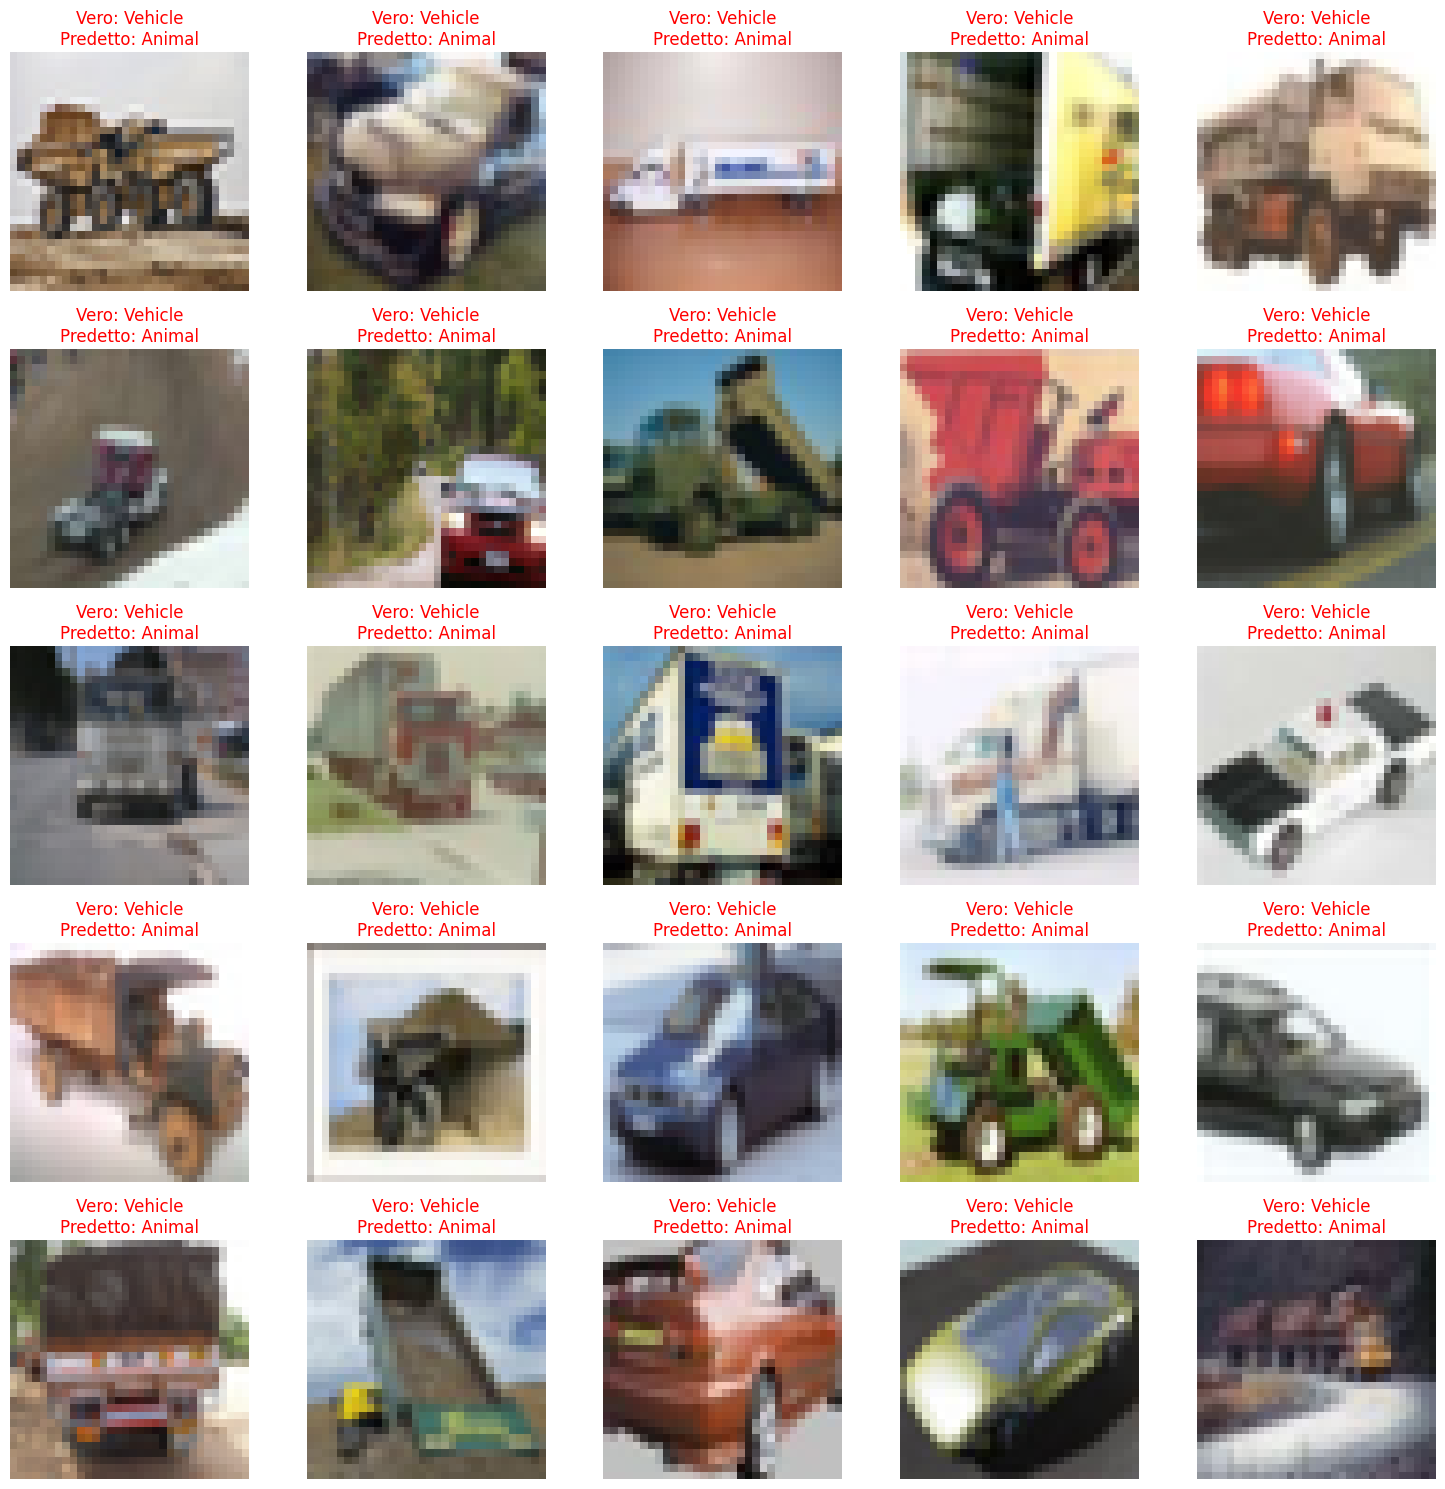

In [ ]:
# Genero un secondo blocco di codice per valutare visivamente errori commessi

misclassified_indices = np.where(y_pred.reshape(-1) != y_test_filtered.reshape(-1))[0]
num_misclassified = len(misclassified_indices)


if num_misclassified > 0:
    print(f"\nVisualizzazione di {min(25, num_misclassified)} immagini misclassificate:")
    plt.figure(figsize=(15, 15))
    for i in range(min(25, num_misclassified)):
        index = misclassified_indices[i]
        plt.subplot(5, 5, i + 1)
        plt.imshow(x_test_filtered[index])
        true_label = 'Animal' if y_test_filtered[index][0] == 1 else 'Vehicle'
        predicted_label = 'Animal' if y_pred[index][0] == 1 else 'Vehicle'
        plt.title(f"Vero: {true_label}\nPredetto: {predicted_label}", color='red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("\nNessuna immagine è stata classificata erroneamente.")

**ANALISI DEI RISULTATI:**

-*Valutazione delle categorie di immagini confuse sistematicamente.*

Analizzando l'output del codice sulla misclassificazione di alcune immagini; mi viene di pensare che ci possa essere un Bias nel Dataset. Ipotizzo infatti che il mio training set contiene una quantità significativa di animali con tonalità di rosso (penso a volpi, scoiattoli rossi, alcune razze di cani o gatti con mantelli rossicci, uccelli con piumaggio rosso, ecc.) e il modello ha imparato ad associare il colore rosso alla classe "animale". Ciò potrebbe portare il modello a generalizzare male e applicare questa associazione anche alle auto rosse.

-*Esame delle immagini errate e riflessione su possibili migliorie al modello.*

Sulla base di quanto precedentemente espresso si potrebbe, nell'ottica di un miglioramento del modello, pensare al:

--Ribilanciamento delle Classi: Se si nota una significativa disparità nel numero di immagini tra le classi di veicoli e animali (anche all'interno delle sottocategorie), si potrebbero considerare tecniche di bilanciamento del dataset.
--Espansione del Dataset: si potrebbe utilizzare dataset più ampi e diversificati che includano una maggiore varietà di condizioni ambientali (diverse illuminazioni, angolazioni, condizioni meteorologiche), sfondi e pose sia per veicoli che per animali.
--Variazioni di Colore e Tonalità: Se l'ipotesi del bias sul colore rosso è corretta, si potrebbe cercare di includere nel training set una distribuzione più equilibrata di colori per entrambe le classi. Potremmo anche applicare variazioni di colore (hue, saturation, brightness) come parte della data augmentation per rendere il modello più robusto alle variazioni cromatiche.

**RISULTATO FINALE**



### Presentazione della Rete Neurale Convoluzionale

Il modello che hO sviluppato è una rete neurale convoluzionale (CNN) composta da tre blocchi principali di convoluzione e pooling, seguiti da strati completamente connessi. La CNN è stata progettata per distinguere tra immagini di veicoli e animali, utilizzando il dataset CIFAR-10. Ecco una panoramica della struttura del modello:

1. **Convoluzione e Normalizzazione**:
   - Tre blocchi di convoluzione con kernel 3x3 e attivazione ReLU.
   - Batch Normalization per stabilizzare e accelerare la convergenza.
   - MaxPooling per ridurre le dimensioni spaziali e mantenere le caratteristiche importanti.

2. **Dropout**:
   - Implementato per ridurre il rischio di overfitting, migliorando la generalizzazione del modello.

3. **Strato Completamente Connesso**:
   - Un livello denso con 128 neuroni e attivazione ReLU.
   - Dropout per ulteriore regolarizzazione.
   - Strato finale con attivazione sigmoid per la classificazione binaria (veicolo vs animale).

### Discussione delle Metriche Utilizzate

Il modello è stato valutato utilizzando diverse metriche, tra cui accuratezza, precisione, e una matrice di confusione:

1. **Accuratezza**:
   - La precisione finale del modello sul test set è stata di circa \( {test\_accuracy:.2f} \).
   - L'accuratezza rappresenta la proporzione di immagini correttamente classificate.

2. **Precisione**:
   - La precisione misura la qualità delle predizioni positive, indicando la proporzione di immagini correttamente identificate come veicoli o animali rispetto al totale delle predizioni.

3. **Matrice di Confusione**:
   - La matrice di confusione fornisce un'analisi dettagliata delle prestazioni del modello, mostrando come le immagini siano classificate tra le due classi.
   - È stata visualizzata utilizzando una heatmap per facilitare l'interpretazione.

### Analisi Critica delle Prestazioni e Limitazioni del Modello

1. **Prestazioni**:
   - Il modello ha dimostrato buone capacità di discriminazione tra veicoli e animali, ma il test ha evidenziato alcune misclassificazioni.
   - La visualizzazione delle immagini erroneamente classificate ha suggerito (mia ipotesi) un possibile bias dovuto al colore, in particolare il rosso, che potrebbe influenzare la decisione del modello.

2. **Potenziali Limitazioni**:
   - **Bias nel Dataset**: La presenza di bias nei dati di allenamento, come l'associazione tra colore rosso e animali, può influenzare negativamente le prestazioni del modello.
   - **Varietà Limitata nel Dataset**: Il dataset CIFAR-10, sebbene utile, potrebbe non rappresentare adeguatamente la variabilità delle condizioni reali (diversi ambienti, illuminazioni, ecc.).

3. **Possibili Migliorie**:
   - **Ribilanciamento delle Classi**: si potrebbe considerare tecniche per bilanciare il dataset in termini di distribuzione delle classi.
   - **Espansione del Dataset**: sarebbe opportuno utilizzare dataset più ampi e diversificati per includere una gamma più ampia di condizioni ambientali.
   - **Variazioni di Colore**: potrebbe essere utile implementare ulteriori tecniche di data augmentation per ridurre il bias cromatico.
